In [29]:
# import libraries 

import pandas as pd
import numpy as np
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict

q1_raw = pd.read_excel('./cerc_results/overall comparison.xlsx', sheet_name="QUERY 1")
q2_raw = pd.read_excel('./cerc_results/overall comparison.xlsx', sheet_name="QUERY 2")
q3_raw = pd.read_excel('./cerc_results/overall comparison.xlsx', sheet_name="QUERY 3")

# the v2 results (claude's refactored queries) are actually bad!! stick with the original 

q1_claude = pd.read_excel('./cerc_results/overall comparison v2.xlsx', sheet_name="QUERY 1")
q2_claude = pd.read_excel('./cerc_results/overall comparison v2.xlsx', sheet_name="QUERY 2")
q3_claude = pd.read_excel('./cerc_results/overall comparison v2.xlsx', sheet_name="QUERY 3")

## deal with query 1

### clean query 1

In [30]:
q1_raw = q1_raw.rename(columns={"OA citation count ": "OA citation count", "SciVal titles ": "SciVal titles", "SV citation count ": "SV citation count"})
q1_raw.head()

,OpenAlex titles,OpenAlex DOI,OA citation count,SciVal titles,SciVal DOI,SV citation count,Unnamed: 6,Unnamed: 7,Total number of Publications,Unnamed: 9
0,Flood Detection and Susceptibility Mapping Usi...,10.3390/rs12020266,355.0,Planck 2018 results: V. CMB power spectra and ...,10.1051/0004-6361/201936386,788.0,NaN,NaN,OpenAlex,968.000000
1,SAPIEN: A SimulAted Part-Based Interactive ENv...,10.1109/cvpr42600.2020.01111,353.0,SuperYOLO: Super Resolution Assisted Object De...,10.1109/TGRS.2023.3258666,458.0,NaN,NaN,SciVal,950.000000
2,Changes in Annual Extremes of Daily Temperatur...,10.1175/jcli-d-19-1013.1,329.0,Sapien: A simulated part-based interactive ENv...,10.1109/CVPR42600.2020.01111,377.0,NaN,NaN,OA in SV %,0.662190
3,A processâ€based metacommunity framework link...,10.1111/ele.13568,323.0,Habitat 2.0: Training Home Assistants to Rearr...,NaN,319.0,NaN,NaN,SV in OA %,0.676842
4,SuperYOLO: Super Resolution Assisted Object De...,10.1109/tgrs.2023.3258666,284.0,Flood detection and susceptibility mapping usi...,10.3390/rs12020266,317.0,NaN,NaN,NaN,NaN


#### oa

In [31]:
q1_oa = q1_raw[['OpenAlex titles', 'OpenAlex DOI', 'OA citation count']].dropna(how="all")
q1_oa.head()

,OpenAlex titles,OpenAlex DOI,OA citation count
0,Flood Detection and Susceptibility Mapping Usi...,10.3390/rs12020266,355.0
1,SAPIEN: A SimulAted Part-Based Interactive ENv...,10.1109/cvpr42600.2020.01111,353.0
2,Changes in Annual Extremes of Daily Temperatur...,10.1175/jcli-d-19-1013.1,329.0
3,A processâ€based metacommunity framework link...,10.1111/ele.13568,323.0
4,SuperYOLO: Super Resolution Assisted Object De...,10.1109/tgrs.2023.3258666,284.0


In [32]:
citations = pd.to_numeric(q1_oa['OA citation count'], errors='coerce')

oa_q1_stats = pd.DataFrame()
oa_q1_stats['database'] = ["OA"]
oa_q1_stats['query'] = ['Q1']
oa_q1_stats['count'] = [len(q1_oa)]
oa_q1_stats['have DOI'] = [len(q1_oa[q1_oa['OpenAlex DOI'].notna()])]
oa_q1_stats['mean citations'] = [np.nanmean(citations)]
oa_q1_stats['median citations'] = [np.nanmedian(citations)]
oa_q1_stats['q1 citations'] = [np.nanpercentile(citations, 25)]
oa_q1_stats['q3 citations'] = [np.nanpercentile(citations, 75)]

oa_q1_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q1,968,965,13.216132,3.0,1.0,13.0


#### claude quert

In [33]:
q1_claude.columns

Index(['OpenAlex titles', 'OpenAlex DOI', 'OA citation count ',
       'SciVal titles ', 'SciVal DOI', 'SV citation count'],
      dtype='object')

In [34]:
q1_claude = q1_claude[['OpenAlex titles', 'OpenAlex DOI', 'OA citation count ']].dropna(how="all")
q1_claude['OpenAlex DOI'] = q1_claude['OpenAlex DOI'].str.replace('https://doi.org/', '')
q1_claude.head()

,OpenAlex titles,OpenAlex DOI,OA citation count
0,SuperYOLO: Super Resolution Assisted Object De...,10.1109/tgrs.2023.3258666,297
1,Change Detection in Remote Sensing Image Data ...,10.3390/electronics11030431,127
2,Flood Detection and Susceptibility Mapping Usi...,10.3390/rs12020266,360
3,Landslide Susceptibility Mapping Using Machine...,10.3390/ijerph17144933,149
4,Cloud and Cloud Shadow Segmentation for Remote...,10.1109/jstars.2021.3070786,65


In [35]:
citations = pd.to_numeric(q1_claude['OA citation count '], errors='coerce')

q1_claude_stats = pd.DataFrame()
q1_claude_stats['database'] = ["OA w Claude"]
q1_claude_stats['query'] = ['Q1']
q1_claude_stats['count'] = [len(q1_claude)]
q1_claude_stats['have DOI'] = [len(q1_claude[q1_claude['OpenAlex DOI'].notna()])]
q1_claude_stats['mean citations'] = [np.nanmean(citations)]
q1_claude_stats['median citations'] = [np.nanmedian(citations)]
q1_claude_stats['q1 citations'] = [np.nanpercentile(citations, 25)]
q1_claude_stats['q3 citations'] = [np.nanpercentile(citations, 75)]

q1_claude_stats


,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA w Claude,Q1,2317,2307,15.844103,5.0,1.0,15.0


### analysis of q1

## deal with q2

### clean query2

In [36]:
print(q2_raw.columns)

Index(['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations', 'SciVal Title',
       'SciVal DOI', 'SciVal Citations', 'Unnamed: 6',
       'Total number of Publications', 'Unnamed: 8'],
      dtype='object')


In [37]:
q2_raw = q2_raw.rename(columns={"OpenAlex Title ": "OpenAlex Title"})
q2_raw.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations,SciVal Title,SciVal DOI,SciVal Citations,Unnamed: 6,Total number of Publications,Unnamed: 8
0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,294.0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,279,NaN,OpenAlex,199.000000
1,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,124.0,Opioid agonist treatment and risk of mortality...,10.1136/bmj.m772,170,NaN,SciVal,329.000000
2,Phase transition enhanced superior elasticity ...,10.1126/sciadv.aba5847,123.0,Optical observation of single spins in silicon,10.1038/s41586-022-04821-y,142,NaN,OA in SV %,0.748744
3,Material properties and structure of natural g...,10.1038/s41598-020-75393-y,82.0,"Dimensional diversity (0D, 1D, 2D, and 3D) in ...",10.1039/d3ta06953b,122,NaN,SV in OA %,0.452888
4,Recent progress in bismuth-based high Curie te...,10.1016/j.cossms.2022.101016,73.0,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,121,NaN,NaN,NaN


#### oa

In [38]:
q2_oa = q2_raw[['OpenAlex Title', 'OpenAlex DOI', 'OpenAlex Citations']].dropna(how="all")
q2_oa.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations
0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,294.0
1,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,124.0
2,Phase transition enhanced superior elasticity ...,10.1126/sciadv.aba5847,123.0
3,Material properties and structure of natural g...,10.1038/s41598-020-75393-y,82.0
4,Recent progress in bismuth-based high Curie te...,10.1016/j.cossms.2022.101016,73.0


In [39]:
citations = pd.to_numeric(q2_oa['OpenAlex Citations'], errors='coerce')

oa_q2_stats = pd.DataFrame()
oa_q2_stats['database'] = ["OA"]
oa_q2_stats['query'] = ['Q2']
oa_q2_stats['count'] = [len(q2_oa)]
oa_q2_stats['have DOI'] = [len(q2_oa[q2_oa['OpenAlex DOI'].notna()])]
oa_q2_stats['mean citations'] = [np.nanmean(citations)]
oa_q2_stats['median citations'] = [np.nanmedian(citations)]
oa_q2_stats['q1 citations'] = [np.nanpercentile(citations, 25)]
oa_q2_stats['q3 citations'] = [np.nanpercentile(citations, 75)]

oa_q2_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q2,199,199,16.823232,5.5,1.0,22.0


#### claude query

In [40]:
q2_claude.columns

Index(['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations', 'SciVal Title',
       'SciVal DOI', 'SciVal Citations'],
      dtype='object')

In [41]:
q2_claude = q2_claude[['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations']].dropna(how="all")
q2_claude['OpenAlex DOI'] = q2_claude['OpenAlex DOI'].str.replace('https://doi.org/', '')
q2_claude.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations
0,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,127
1,Material properties and structure of natural g...,10.1038/s41598-020-75393-y,86
2,Performance analysis of several electron/hole ...,10.1016/j.optmat.2021.111258,64
3,A 3D-printed neuromorphic humanoid hand for gr...,10.1016/j.isci.2022.104119,32
4,Review of transfer learning in modeling additi...,10.1016/j.addma.2022.103357,69


In [42]:
citations = pd.to_numeric(q2_claude['OpenAlex Citations'], errors='coerce')

q2_claude_stats = pd.DataFrame()
q2_claude_stats['database'] = ["OA w Claude"]
q2_claude_stats['query'] = ['Q2']
q2_claude_stats['count'] = [len(q2_claude)]
q2_claude_stats['have DOI'] = [len(q2_claude[q2_claude['OpenAlex DOI'].notna()])]
q2_claude_stats['mean citations'] = [np.nanmean(citations)]
q2_claude_stats['median citations'] = [np.nanmedian(citations)]
q2_claude_stats['q1 citations'] = [np.nanpercentile(citations, 25)]
q2_claude_stats['q3 citations'] = [np.nanpercentile(citations, 75)]

q2_claude_stats


,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA w Claude,Q2,506,504,21.182004,7.0,1.0,23.0


### analysis of q2

## deal with q3

### clean query 3

In [43]:
print(q3_raw.columns)

Index(['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations',
       'SciVal Title ', 'SciVal DOI', 'SciVal Citations', 'Unnamed: 6',
       'Total number of Publications', 'Unnamed: 8'],
      dtype='object')


In [44]:
q3_raw = q3_raw.rename(columns={"OpenAlex Title ": "OpenAlex Title", "SciVal Title ": "SciVal Title"})
q3_raw.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations,SciVal Title,SciVal DOI,SciVal Citations,Unnamed: 6,Total number of Publications,Unnamed: 8
0,COVID-19: the gendered impacts of the outbreak,10.1016/s0140-6736(20)30526-2,1743.0,The Lancet Commission on lessons for the futur...,10.1016/S0140-6736(22)01585-9,601,NaN,OpenAlex,718.000000
1,Human resource management in the age of genera...,10.1111/1748-8583.12524,671.0,Human resource management in the age of genera...,10.1111/1748-8583.12524,600,NaN,SciVal,768.000000
2,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,553.0,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,445,NaN,OA in SV %,0.600279
3,How Right-Leaning Media Coverage of COVID-19 F...,10.1017/s0008423920000396,441.0,How right-leaning media coverage of Covid-19 f...,10.1017/S0008423920000396,341,NaN,SV in OA %,0.559896
4,Digital agricultural technologies for food los...,10.1016/j.jclepro.2021.129099,203.0,The Knowns and Unknowns of Policy Instrument A...,10.1177/2158244019900568,297,NaN,NaN,NaN


#### oa

In [45]:
q3_oa = q3_raw[['OpenAlex Title', 'OpenAlex DOI', 'OpenAlex Citations']].dropna(how="all")
q3_oa.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations
0,COVID-19: the gendered impacts of the outbreak,10.1016/s0140-6736(20)30526-2,1743.0
1,Human resource management in the age of genera...,10.1111/1748-8583.12524,671.0
2,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,553.0
3,How Right-Leaning Media Coverage of COVID-19 F...,10.1017/s0008423920000396,441.0
4,Digital agricultural technologies for food los...,10.1016/j.jclepro.2021.129099,203.0


In [46]:
citations = pd.to_numeric(q3_oa['OpenAlex Citations'], errors='coerce')

oa_q3_stats = pd.DataFrame()
oa_q3_stats['database'] = ["OA"]
oa_q3_stats['query'] = ['Q3']
oa_q3_stats['count'] = [len(q3_oa)]
oa_q3_stats['have DOI'] = [len(q3_oa[q3_oa['OpenAlex DOI'].notna()])]
oa_q3_stats['mean citations'] = [np.nanmean(citations)]
oa_q3_stats['median citations'] = [np.nanmedian(citations)]
oa_q3_stats['q1 citations'] = [np.nanpercentile(citations, 25)]
oa_q3_stats['q3 citations'] = [np.nanpercentile(citations, 75)]

oa_q3_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q3,718,712,16.239554,3.0,0.0,13.0


In [47]:
q3_claude.columns

Index(['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations',
       'SciVal Title ', 'SciVal DOI', 'SciVal Citations'],
      dtype='object')

#### claude query

In [48]:
q3_claude = q3_claude[['OpenAlex Title ', 'OpenAlex DOI', 'OpenAlex Citations']].dropna(how="all")
q3_claude['OpenAlex DOI'] = q3_claude['OpenAlex DOI'].str.replace('https://doi.org/', '')
q3_claude.head()

,OpenAlex Title,OpenAlex DOI,OpenAlex Citations
0,How Right-Leaning Media Coverage of COVID-19 F...,10.1017/s0008423920000396,446
1,Human resource management in the age of genera...,10.1111/1748-8583.12524,712
2,Does resource insecurity drive HIVâ€related s...,10.1002/jia2.25913,32
3,The â€œSticky Notesâ€ Method: Adapting Interp...,10.1177/10497323211002489,27
4,When Science Becomes Embroiled in Conflict: Re...,10.1177/00027162221084663,39


In [49]:
citations = pd.to_numeric(q3_claude['OpenAlex Citations'], errors='coerce')

q3_claude_stats = pd.DataFrame()
q3_claude_stats['database'] = ["OA w Claude"]
q3_claude_stats['query'] = ['Q3']
q3_claude_stats['count'] = [len(q3_claude)]
q3_claude_stats['have DOI'] = [len(q3_claude[q3_claude['OpenAlex DOI'].notna()])]
q3_claude_stats['mean citations'] = [np.nanmean(citations)]
q3_claude_stats['median citations'] = [np.nanmedian(citations)]
q3_claude_stats['q1 citations'] = [np.nanpercentile(citations, 25)]
q3_claude_stats['q3 citations'] = [np.nanpercentile(citations, 75)]

q3_claude_stats


,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA w Claude,Q3,2178,2159,15.22217,4.0,1.0,14.0


### analysis of q3

## add up results

In [50]:
descriptive_stats = pd.DataFrame()
descriptive_stats = pd.concat([oa_q1_stats, q1_claude_stats, oa_q2_stats, q2_claude_stats, oa_q3_stats, q3_claude_stats]).reset_index().drop(columns=['index'])

descriptive_stats

,database,query,count,have DOI,mean citations,median citations,q1 citations,q3 citations
0,OA,Q1,968,965,13.216132,3.0,1.0,13.0
1,OA w Claude,Q1,2317,2307,15.844103,5.0,1.0,15.0
2,OA,Q2,199,199,16.823232,5.5,1.0,22.0
3,OA w Claude,Q2,506,504,21.182004,7.0,1.0,23.0
4,OA,Q3,718,712,16.239554,3.0,0.0,13.0
5,OA w Claude,Q3,2178,2159,15.222170,4.0,1.0,14.0


In [51]:
import matplotlib as plt
from matplotlib_venn import venn2

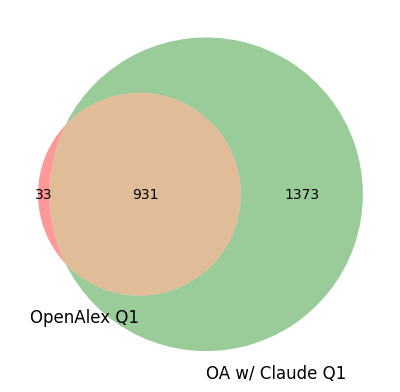

In [52]:
q1_comp = venn2([set(q1_oa['OpenAlex DOI'].dropna()), set(q1_claude['OpenAlex DOI'].dropna())],
      set_labels=('OpenAlex Q1', 'OA w/ Claude Q1'))

q1_comp

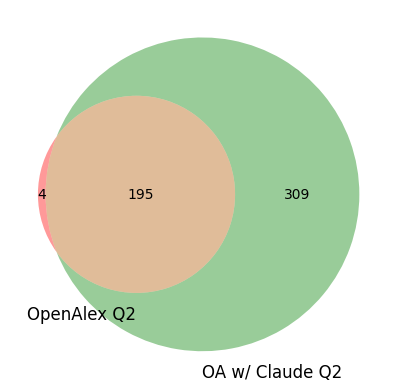

In [53]:
q2_comp = venn2([set(q2_oa['OpenAlex DOI'].dropna()), set(q2_claude['OpenAlex DOI'].dropna())],
      set_labels=('OpenAlex Q2', 'OA w/ Claude Q2'))

q2_comp

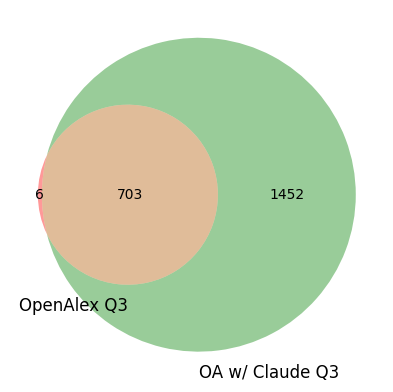

In [54]:
q3_comp = venn2([set(q3_oa['OpenAlex DOI'].dropna()), set(q3_claude['OpenAlex DOI'].dropna())],
      set_labels=('OpenAlex Q3', 'OA w/ Claude Q3'))

q3_comp